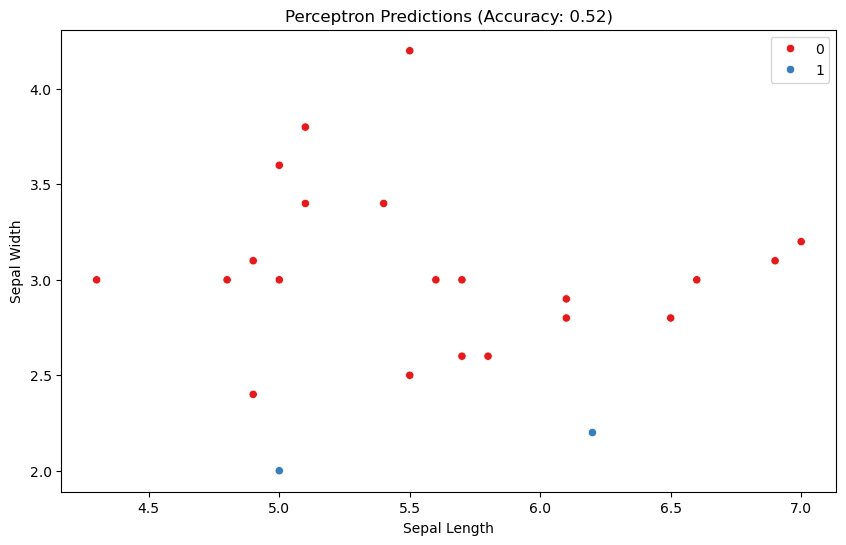

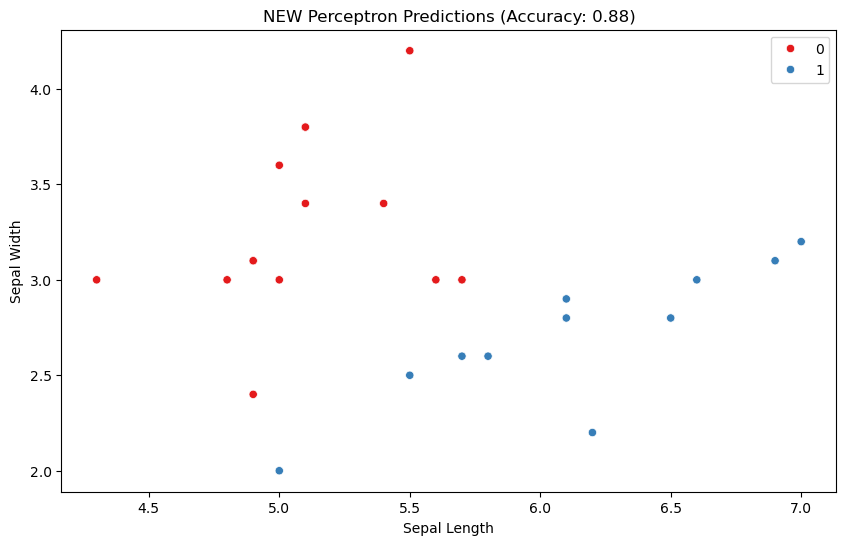

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Use the perceptron class from the notebooks
class Perceptron:

    def __init__(self, n_inputs, lr=0.1, seed=12345):
        """
        Constructor:
            self.W: weights, one for each input
            self.b: bias, one for the entire perceptron
            self.lr: learning rate
        """
        np.random.seed(seed)
        self.W = np.random.randn(n_inputs)
        self.b = 0.0
        self.lr = lr

    def activation(self, z):
        """
        Simulates the binary activation
        """
        return 1 if z >= 0 else 0 

    def predict(self, x):
        """
        Applies the linear transformation, then passes the result through activation
        """
        z = np.dot(self.W, x) + self.b
        return self.activation(z)

    def train(self, X, y, epochs=10):
        """
            Iterates through the dataset for a given number of epochs, updating the weights and bias
        """
        for _ in range(epochs):
            for xi, yi in zip(X, y):
                # Make prediction
                pred = self.predict(xi)

                # Compute prediction error
                error = yi - pred

                # Update all weights and bias
                self.W += self.lr * error * xi
                self.b += self.lr * error


if __name__ == '__main__':
    # Load Data
    df = pd.read_csv('../data/iris.csv', encoding='latin-1')


    # choose which two iris types you want to keep
    df = df[df['iris_type'] != 'Iris-virginica']


    # Convert iris_type to 0 or 1
    df['iris_type'] = df['iris_type'].map({'Iris-setosa': 0, 'Iris-versicolor': 1})
    # df['iris_type'].unique()


    # Select two features for input
    X = df[['sepal_length', 'sepal_width']]
    y = df['iris_type']


    # Use train_test_split to create training and testing sets
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y)


    # Set a learning rate and number of epochs
    lr = 0.1
    epochs = 10


    # Train the model
    perceptron = Perceptron(n_inputs=2, lr=lr)
    perceptron.train(X_train.values, y_train.values, epochs=epochs)


    # Use the model's predict function on the testing set, save these results
    y_pred = [perceptron.predict(x) for x in X_test.values]


    # Use accuracy_score to determine model's accuracy
    from sklearn.metrics import accuracy_score
    accuracy = accuracy_score(y_test, y_pred)


    # Plot a scatterplot of your data colored by predictions
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_test['sepal_length'], y=X_test['sepal_width'], hue=y_pred, palette='Set1')
    plt.title(f'Perceptron Predictions (Accuracy: {accuracy:.2f})')
    plt.xlabel('Sepal Length')
    plt.ylabel('Sepal Width')
    plt.show()


    # Try adjusting learning rate and number of epochs
    lr = 0.01
    epochs = 50


    # Retrain the model with new parameters
    perceptron = Perceptron(n_inputs=2, lr=lr)
    perceptron.train(X_train.values, y_train.values, epochs=epochs)
    y_pred = [perceptron.predict(x) for x in X_test.values]
    accuracy = accuracy_score(y_test, y_pred)


    # Did the model improve or get worse when modifying learning rate and epochs?
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_test['sepal_length'], y=X_test['sepal_width'], hue=y_pred, palette='Set1')
    plt.title(f'NEW Perceptron Predictions (Accuracy: {accuracy:.2f})')
    plt.xlabel('Sepal Length')
    plt.ylabel('Sepal Width')
    plt.show()



**Did the model improve or get worse when modifying learning rate and epochs?**

The learning model got much better. From 0.52 to 0.88, gaining 36 points.

**If the model made no errors on training data, does that mean it's perfect?**

No, we can train and test, but you can't know everything that will happen in a live environment.

**What are the risks of using too many epochs or too large of a learning rate?**

Training the model will start to become expensive on the system or computer.

**If you tried this on data that not linearly separable, what do you expect?**

The perceptron wouldn't improve or have a high accuracy. The goal would be to manipulate or feature engineer until it is linearly separable.
